In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### TAMS Intervention Method Event, FY 2023/24

Note that the FY2324.csv table captures the 2023/24 financial year!

In [2]:
ime_df = pd.read_csv("./FY2324.csv.gz", parse_dates=['Intervention method event start datetime', 'Creation datetime'] )

ime_df.sample(5)

,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime
2173351,e1360f9d-3e71-4efb-a503-d912161c564a,6d00015b-9978-4a71-976f-b2b24dfef4f3,2023-12-01 02:13:20,INT-13487827-G9Y6K-2023-12-01 05:13:39,445290003,445290000,NaN,6063bfca-d4aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2023-11-30 18:13:39
1368897,3036190b-3cbd-45a3-afa1-5865eb7cf8fe,ac44bf74-c0f3-4d93-ab39-70805212b4b5,2023-09-19 11:02:29,INT-12918143-G4M2R-2023-09-19 11:02:44,445290005,445290003,NaN,4e78e69e-5173-ec11-8943-002248111ae0,NaN,NaN,NaN,Secondary Examination Area,2023-09-19 01:02:44
2638863,b6bee296-649e-4cd4-9df3-193f3a6046aa,08ee5629-668e-4ba6-ade5-d8f51125d549,2023-09-27 08:48:38,INT-12979193-L7R4Y-2023-09-27 08:48:52,445290003,445290001,NaN,79226059-34ed-ec11-bb3d-000d3acbfef9,NaN,NaN,X-ray referral,Secondary Examination Area,2023-09-26 22:48:52
1063720,42e2e57d-bda5-4b76-b1f5-57513aa7ecfb,1c4f2617-7849-474c-9557-576456aad5d4,2024-04-20 10:02:39,INT-14603515-K7L2M-2024-04-20 10:03:13,445290005,445290003,NaN,6fa47095-cfaa-ea11-a814-000d3a6a9c0e,NaN,NaN,NaN,Secondary Examination Area,2024-04-20 00:03:13
1828141,be9118dc-e6cf-46c8-a1bb-e89e1e2c4462,48025d05-7da8-4e10-9bac-9644d986549a,2023-12-05 11:05:50,INT-13525624-F5W7R-2023-12-05 12:06:5,445290002,445290000,NaN,1a406cfe-19f1-ec11-bb3d-000d3acc2ca6,92fb32a9-bc24-ed11-9db1-00224812b5bf,90e1bfd8-d6aa-ea11-a814-000d3a6a96b8,NaN,Secondary Examination Area,2023-12-05 01:06:05


In [3]:
ime_df['Intervention method event start datetime'].describe()

count                          3114364
mean     2023-12-28 19:33:44.600482048
min                2023-07-01 00:00:12
25%         2023-09-28 07:18:08.500000
50%                2023-12-28 16:24:18
75%         2024-03-30 18:36:23.500000
max                2024-06-30 23:59:58
Name: Intervention method event start datetime, dtype: object

There exist records with identical 'Intervention method event ID' values:

In [4]:
ime_df['Intervention method event ID'].nunique(), (ime_df['Intervention method event ID'].value_counts() > 1).sum(), ime_df['Intervention method event ID'].value_counts().head()

(3113934,
 142,
 Intervention method event ID
 Its currently blank :)-2023-11-14 23:03:28    7
 Its currently blank :)-2024-03-05 02:36:57    4
 Its currently blank :)-2024-03-05 02:36:56    3
 INT-12917458-N5Z4B-2023-09-19 10:14:44        2
 INT-14089097-Z7N1F-2024-02-11 10:45:15        2
 Name: count, dtype: int64)

In [5]:
for c in ('Intervention method ID', 'Intervention outcome ID', 'Detector dog GUID', 'Detector dog handler GUID', 'Location'):
    ime_df[c] = ime_df[c].astype("category")

In [6]:
ime_df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3114364 entries, 0 to 3114363
Data columns (total 13 columns):
 #   Column                                    Dtype         
---  ------                                    -----         
 0   Intervention GUID                         object        
 1   Intervention method event GUID            object        
 2   Intervention method event start datetime  datetime64[ns]
 3   Intervention method event ID              object        
 4   Intervention method ID                    category      
 5   Intervention outcome ID                   category      
 6   Intervention method event comment         object        
 7   Intervention officer GUID                 object        
 8   Detector dog GUID                         category      
 9   Detector dog handler GUID                 category      
 10  Reason summary                            object        
 11  Location                                  category      
 12  Creation datet

Sort the table by the intervention start datetime (and 'Intervention method event ID' which notably also includes a timestamp, when start time is idential) for each officer:

In [7]:
ime_df = ime_df.sort_values(by=['Intervention officer GUID', 'Intervention method event start datetime', 'Intervention method event ID'], ascending=[True, True, True], ignore_index=True)

Add a new column 'time_btwn' as a time difference between consecutive interventions:

In [8]:
ime_df = ime_df.assign(time_btwn=ime_df.groupby('Intervention officer GUID')['Intervention method event start datetime'].diff().shift(-1))

The statistics shows a large skew (with tne median of only 21 sec, and the mean well over an hour):

In [9]:
ime_df['time_btwn'].describe()

count                      3113735
mean     0 days 01:22:28.521264654
std      0 days 19:23:25.634983372
min                0 days 00:00:00
25%                0 days 00:00:00
50%                0 days 00:00:21
75%                0 days 00:04:41
max              259 days 19:37:52
Name: time_btwn, dtype: object

The log scale is needed to show the distribution past the low-end peak:

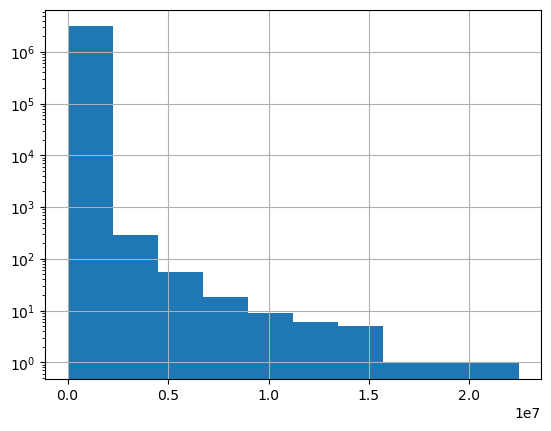

In [10]:
# ime_df['time_btwn'].astype('timedelta64[s]').hist(log=True);
# Since 3.12.4 this needs to firts convert timdelta to float for plotting. Divide by np.timedlta of 1s:
ime_df['time_btwn'].astype('timedelta64[s]').div(np.timedelta64(1, 's')).hist(log=True);

In [11]:
ime_df['time_btwn'] = ime_df['time_btwn'].fillna(pd.Timedelta(seconds=0))
ime_df['time_btwn'].isna().sum()

0

The following transform will create a new column 'start_dtime' which will separate "simultaneous" intervention starts by a part of a second
(and also add extra part of a second to the subsequent interventions).
Then we add the 'Intervention method event start datetime' value to it:

In [12]:
ime_df = ime_df.assign(start_dtime=ime_df.groupby('Intervention officer GUID')['time_btwn'].transform(lambda x: x.shift().lt(pd.to_timedelta("1 seconds")).cumsum()))

In [13]:
ime_df.head()

,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime,time_btwn,start_dtime
0,b698dc54-98f8-46eb-955a-a781b76ccff3,2fa17a5f-ab1e-4f15-919a-bd759ad91504,2023-07-02 06:06:57,INT-12256152-N4L6W-2023-07-02 06:07:20,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,90bb7692-f0cf-eb11-8235-0022481542dd,002727cb-77a9-eb11-9442-0022480fe6d6,NaN,Secondary Examination Area,2023-07-01 20:07:20,0 days 00:00:00,0
1,6220e940-cdb3-459b-9845-4cb53390af16,e7eb63bf-c9dd-4896-87f9-a5e33dea0eb7,2023-07-02 06:06:57,INT-12256153-C5H6S-2023-07-02 06:07:20,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,90bb7692-f0cf-eb11-8235-0022481542dd,002727cb-77a9-eb11-9442-0022480fe6d6,NaN,Secondary Examination Area,2023-07-01 20:07:20,0 days 00:00:00,1
2,e4405fc1-54fd-4083-b704-4ef9ff6e1c67,240a1761-1636-4f5a-934a-b1c2652500e8,2023-07-02 06:06:57,INT-12256154-T4L6D-2023-07-02 06:07:20,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,90bb7692-f0cf-eb11-8235-0022481542dd,002727cb-77a9-eb11-9442-0022480fe6d6,NaN,Secondary Examination Area,2023-07-01 20:07:20,0 days 00:00:00,2
3,d86f7847-38de-4871-a6de-c7d05902b766,4a45bbe2-c46a-48b6-aaf0-f672c68b17ef,2023-07-02 06:06:57,INT-12256155-T0F6F-2023-07-02 06:07:20,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,90bb7692-f0cf-eb11-8235-0022481542dd,002727cb-77a9-eb11-9442-0022480fe6d6,NaN,Secondary Examination Area,2023-07-01 20:07:20,0 days 00:01:28,3
4,1ef37cbe-2d79-43f3-8e37-211c82ff91da,7de1d9a7-c415-4cfd-9006-cf566f468a53,2023-07-02 06:08:25,INT-12256163-M6F6Z-2023-07-02 06:08:32,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,90bb7692-f0cf-eb11-8235-0022481542dd,002727cb-77a9-eb11-9442-0022480fe6d6,NaN,Secondary Examination Area,2023-07-01 20:08:32,0 days 00:00:00,3


Interventions with identical start datetimes often seem to get assigned as non-cluster members (with the label -1) by the DBSCAN, so we separate them by a fraction of a second:

In [14]:
ime_df['start_dtime'] = pd.to_timedelta(ime_df['start_dtime'] / 100.0 , unit="s")  + ime_df['Intervention method event start datetime']

This results in a tiny dilation of 2 min and 42 sec over the year:

In [15]:
(ime_df['start_dtime'] - ime_df['Intervention method event start datetime']).describe()

count                      3114364
mean     0 days 00:00:17.803206988
std      0 days 00:00:18.948622548
min                0 days 00:00:00
25%         0 days 00:00:04.720000
50%         0 days 00:00:12.050000
75%         0 days 00:00:24.280000
max         0 days 00:02:42.360000
dtype: object

Now we test the clustering, using the DBSCAN unsupervised algorithm, to detect batches/clusters of intervention activity.
We set the eps parameters to 1200 sec (20 min) as the max allowed "distance" between interventions in the same cluster.
And we also require the minimum of 5 interventions, min_samples, to make a cluster.

In [16]:
from sklearn.cluster import DBSCAN

In [17]:
dclusters = ime_df.assign(unix_tstamp=ime_df['start_dtime'].apply(lambda x: x.timestamp())).groupby('Intervention officer GUID')\
            ['unix_tstamp'].agg(lambda x: DBSCAN(eps=1200, min_samples=5, p=1).fit(x.values.reshape(-1, 1)))

In [18]:
dclusters.index

Index(['002727cb-77a9-eb11-9442-0022480fe6d6',
       '0030689c-d2aa-ea11-a814-000d3a6a9def',
       '0116c2cb-c1e4-ee11-904d-002248933647',
       '01493553-d3aa-ea11-a814-000d3a6a9def',
       '0161e610-d1aa-ea11-a814-000d3a6a9def',
       '0207bdc5-cfaa-ea11-a814-000d3a6a9c0e',
       '02a85890-d2aa-ea11-a814-000d3a6a9def',
       '02c902d9-d0aa-ea11-a814-000d3a6a9def',
       '030f321a-d4aa-ea11-a814-000d3a6a9def',
       '0315f2f5-d4aa-ea11-a814-000d3a6a9def',
       ...
       'fa728599-d0aa-ea11-a814-000d3a6a9c0e',
       'fa75ad99-87b6-ee11-a568-00224893324d',
       'fb01eafb-d4aa-ea11-a814-000d3a6a9def',
       'fb0ef5c3-d1aa-ea11-a814-000d3a6a9def',
       'fc485647-46ba-ee11-9078-0022489330fc',
       'fcd011f6-d3aa-ea11-a814-000d3a6a9def',
       'fd5fd5b3-d3aa-ea11-a814-000d3a6a9def',
       'fe185c2a-ac8f-ed11-aad1-002248933b6d',
       'ff36baa6-d5aa-ea11-a814-000d3a6a9def',
       'ff485647-46ba-ee11-9078-0022489330fc'],
      dtype='object', name='Intervention officer

In [19]:
clust_ser = dclusters.apply(lambda x: x.labels_).explode()

The lengths and the column/index match:

In [20]:
ime_df.shape, clust_ser.shape

((3114364, 15), (3114364,))

In [21]:
(ime_df['Intervention officer GUID'] == clust_ser.index).all()

True

In [22]:
ime_df['intervention_batch'] = clust_ser.values
ime_df

,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime,time_btwn,start_dtime,intervention_batch
0,b698dc54-98f8-46eb-955a-a781b76ccff3,2fa17a5f-ab1e-4f15-919a-bd759ad91504,2023-07-02 06:06:57,INT-12256152-N4L6W-2023-07-02 06:07:20,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,90bb7692-f0cf-eb11-8235-0022481542dd,002727cb-77a9-eb11-9442-0022480fe6d6,NaN,Secondary Examination Area,2023-07-01 20:07:20,0 days 00:00:00,2023-07-02 06:06:57.000,0
1,6220e940-cdb3-459b-9845-4cb53390af16,e7eb63bf-c9dd-4896-87f9-a5e33dea0eb7,2023-07-02 06:06:57,INT-12256153-C5H6S-2023-07-02 06:07:20,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,90bb7692-f0cf-eb11-8235-0022481542dd,002727cb-77a9-eb11-9442-0022480fe6d6,NaN,Secondary Examination Area,2023-07-01 20:07:20,0 days 00:00:00,2023-07-02 06:06:57.010,0
2,e4405fc1-54fd-4083-b704-4ef9ff6e1c67,240a1761-1636-4f5a-934a-b1c2652500e8,2023-07-02 06:06:57,INT-12256154-T4L6D-2023-07-02 06:07:20,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,90bb7692-f0cf-eb11-8235-0022481542dd,002727cb-77a9-eb11-9442-0022480fe6d6,NaN,Secondary Examination Area,2023-07-01 20:07:20,0 days 00:00:00,2023-07-02 06:06:57.020,0
3,d86f7847-38de-4871-a6de-c7d05902b766,4a45bbe2-c46a-48b6-aaf0-f672c68b17ef,2023-07-02 06:06:57,INT-12256155-T0F6F-2023-07-02 06:07:20,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,90bb7692-f0cf-eb11-8235-0022481542dd,002727cb-77a9-eb11-9442-0022480fe6d6,NaN,Secondary Examination Area,2023-07-01 20:07:20,0 days 00:01:28,2023-07-02 06:06:57.030,0
4,1ef37cbe-2d79-43f3-8e37-211c82ff91da,7de1d9a7-c415-4cfd-9006-cf566f468a53,2023-07-02 06:08:25,INT-12256163-M6F6Z-2023-07-02 06:08:32,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,90bb7692-f0cf-eb11-8235-0022481542dd,002727cb-77a9-eb11-9442-0022480fe6d6,NaN,Secondary Examination Area,2023-07-01 20:08:32,0 days 00:00:00,2023-07-02 06:08:25.030,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3114359,a5a4e176-7b7b-4183-9b9f-0ff7cc43e8eb,b7347dcd-03e3-44e2-938f-5ba32be8e14e,2024-06-27 10:23:04,INT-15120477-Q9F5C-2024-06-27 10:42:48,445290003,445290001,NaN,ff485647-46ba-ee11-9078-0022489330fc,NaN,NaN,X-ray referral,Secondary Examination Area,2024-06-27 00:42:48,0 days 00:00:00,2024-06-27 10:23:11.110,137
3114360,df174c1d-920a-4082-bb8d-28653b684464,9f310294-2618-4399-9f4a-a3f117d4cd83,2024-06-27 10:23:04,INT-15120492-Y4X0L-2024-06-27 10:44:52,445290003,445290000,NaN,ff485647-46ba-ee11-9078-0022489330fc,NaN,NaN,NaN,Secondary Examination Area,2024-06-27 00:44:52,0 days 00:00:00,2024-06-27 10:23:11.120,137
3114361,62dc63b6-4e73-4ed2-954e-97aabcb34014,8dae95de-cdb0-45aa-a6d2-e3d0c2cc2f15,2024-06-27 10:23:04,INT-15120493-Z5X0S-2024-06-27 10:44:52,445290003,445290000,NaN,ff485647-46ba-ee11-9078-0022489330fc,NaN,NaN,NaN,Secondary Examination Area,2024-06-27 00:44:52,0 days 00:21:44,2024-06-27 10:23:11.130,137
3114362,a5a4e176-7b7b-4183-9b9f-0ff7cc43e8eb,a32d90dc-ead6-451b-8e41-b4355cfe8206,2024-06-27 10:44:48,INT-15120477-Q9F5C-2024-06-27 10:44:56,445290005,445290002,NaN,ff485647-46ba-ee11-9078-0022489330fc,NaN,NaN,NaN,Secondary Examination Area,2024-06-27 00:44:56,0 days 02:32:01,2024-06-27 10:44:55.130,-1


About 7.9% of the records didn't fit into a batch (i.e., were assigned the label -1):

In [23]:
print(ime_df['intervention_batch'].eq(-1).sum(), f"{round(ime_df['intervention_batch'].eq(-1).sum() / 33218.40, 1)}%")

263647 7.9%


Often the minimal cluster for an officer is well below the min_samples=10, e.g. the following are 3 or below:

In [24]:
mmm = [print(i, ":", min(np.unique(c.labels_, return_counts=True)[1])) for i, c in enumerate(dclusters) 
       if (i_min := np.argmin(np.unique(c.labels_, return_counts=True)[1])) &
           ( np.unique(c.labels_, return_counts=True)[1][i_min] <= 3 ) &
           (np.unique(c.labels_, return_counts=True)[0][i_min] >= 0 )
      ]

74 : 3
165 : 3
181 : 3
286 : 3
389 : 3
394 : 3
401 : 3
431 : 3
442 : 3
489 : 3
571 : 3
578 : 3
579 : 3


There is only a single officer with larger than 20 interventions in their smallest cluster:

In [25]:
lll = [print(i, ":",  min(np.unique(c.labels_, return_counts=True)[1])) for i, c in enumerate(dclusters) if min(np.unique(c.labels_, return_counts=True)[1]) > 20]

449 : 25


In [26]:
dclusters.index[449]

'b273c0d2-d6aa-ea11-a814-000d3a6a96b8'

The officer "b273c0d2-d6aa-ea11-a814-000d3a6a96b8" had only two batches of intervention activity, bot well in excess of 100:

In [27]:
np.unique(dclusters["b273c0d2-d6aa-ea11-a814-000d3a6a96b8"].labels_, return_counts=True)

(array([0, 1, 2, 3], dtype=int64), array([33, 25, 32, 78], dtype=int64))

In [28]:
np.unique(dclusters["b273c0d2-d6aa-ea11-a814-000d3a6a96b8"].labels_, return_counts=True)

(array([0, 1, 2, 3], dtype=int64), array([33, 25, 32, 78], dtype=int64))

Now adding a new feature 'intervention_count' which is the number of interventions by the same officer starting at the same time (this will be needed to split the time evenly).

Note, however, that there are occurrences of two sub-batches (i.e., subsets of interventions by the same officer at two different times) separated by a SINGLE SECOND, for example:

In [29]:
ime_df.query('`Intervention officer GUID` == "002727cb-77a9-eb11-9442-0022480fe6d6"').\
    query('`Intervention method event start datetime`.ge(@pd.to_datetime("2024-06-02 12:21:29"))').head()

,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime,time_btwn,start_dtime,intervention_batch
19848,9686e4cc-04dd-49ac-8d64-647912e13e99,7b90c7ae-2224-41f9-a5c6-4770145c3210,2024-06-02 12:21:29,INT-14926813-J7C5D-2024-06-02 12:21:40,445290002,445290001,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,8abb7692-f0cf-eb11-8235-0022481542dd,77cd9aa9-e674-ec11-8943-002248920ae0,K9 referral,Secondary Examination Area,2024-06-02 02:21:40,0 days 00:00:00,2024-06-02 12:24:00.640,361
19849,9ef412a6-698b-4169-8681-46b588cbad04,59dcc2ad-ff61-4065-a86b-43b2828eb78b,2024-06-02 12:21:29,INT-14926816-C2C2W-2024-06-02 12:21:47,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,1d88c300-c889-ee11-be36-00224893324d,74e042d3-1475-ec11-8943-002248920ae0,NaN,Secondary Examination Area,2024-06-02 02:21:47,0 days 00:00:00,2024-06-02 12:24:00.650,361
19850,dcfaffe1-141d-41d2-b876-986ae80f155c,e9f884bd-59be-4a35-9941-637899f53831,2024-06-02 12:21:29,INT-14926817-P5Y2L-2024-06-02 12:21:48,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,1d88c300-c889-ee11-be36-00224893324d,74e042d3-1475-ec11-8943-002248920ae0,NaN,Secondary Examination Area,2024-06-02 02:21:48,0 days 00:00:01,2024-06-02 12:24:00.660,361
19851,7d65ddbf-0695-4d16-8de3-a3245ce881d8,ed13b5ee-c796-4793-969f-bbbb88f6bb1e,2024-06-02 12:21:30,INT-14926814-Y2F9N-2024-06-02 12:21:47,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,1d88c300-c889-ee11-be36-00224893324d,74e042d3-1475-ec11-8943-002248920ae0,NaN,Secondary Examination Area,2024-06-02 02:21:47,0 days 00:00:00,2024-06-02 12:24:01.660,361
19852,0da01c33-5c40-45b8-9452-e126deb25699,83ad4a57-fe13-4cfc-b6bf-8aa3b4c455a5,2024-06-02 12:21:30,INT-14926815-K2S8J-2024-06-02 12:21:47,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,1d88c300-c889-ee11-be36-00224893324d,74e042d3-1475-ec11-8943-002248920ae0,NaN,Secondary Examination Area,2024-06-02 02:21:47,0 days 00:01:55,2024-06-02 12:24:01.670,361


Clearly, all such occurrences should be lumped together into a single sub-batch.
So, we create a new temporary column 'rounded_start' with start datetimes rounded to 5 seconds so we can count the associated interventions inside the same sub-batch in the 'intervention_count':

In [30]:
ime_df['intervention_count'] = ime_df.assign(rounded_start=ime_df['Intervention method event start datetime'].round("5s")).\
    groupby(['Intervention officer GUID', 'rounded_start'])\
            ['start_dtime'].transform("nunique")

In [31]:
ime_df['intervention_batch'] = ime_df['intervention_batch'].astype(np.int16)
ime_df['intervention_count'] = ime_df['intervention_count'].astype(np.uint8)

A quick test: are there groups of (officer, start_datetimes) pairs with more than a single batch? Normally one would expect that only a single batch could start at a given datetime.
Let's take a look at the cluster labels at each start datetime. Apparently, there are 22 cases with more than a single batch:

In [32]:
(ime_df.groupby(['Intervention officer GUID', 'Intervention method event start datetime'])['intervention_batch'].nunique() > 1).sum()

22

These are all the rows that exhibit the issue:

In [33]:
# ime_df.groupby(['Intervention officer GUID', ime_df_Br['Amendment_date'].round("5s")]),  rounding may not be necessary, though

with pd.option_context("display.max_rows", None):
    display(ime_df.groupby(['Intervention officer GUID', 'Intervention method event start datetime']).filter(lambda x: x['intervention_batch'].nunique() > 1))

,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime,time_btwn,start_dtime,intervention_batch,intervention_count
150586,7cfc58b9-c641-4c45-b907-ed14773b897e,24381615-c039-41a9-8dc0-cae78dcda49a,2024-01-29 14:49:59,INT-13985137-G6P2K-2024-01-29 14:50:15,445290003,445290000,NaN,0c07bdc5-cfaa-ea11-a814-000d3a6a9c0e,NaN,NaN,NaN,Secondary Examination Area,2024-01-29 03:50:15,0 days 00:00:00,2024-01-29 14:50:08.440,-1,2
150587,cb8e016c-a27a-40b5-8d47-eef6ff58d472,eaf187a9-3768-4ae2-952f-b96dcece0b27,2024-01-29 14:49:59,INT-13985138-X8B6Q-2024-01-29 14:50:15,445290003,445290000,NaN,0c07bdc5-cfaa-ea11-a814-000d3a6a9c0e,NaN,NaN,NaN,Secondary Examination Area,2024-01-29 03:50:15,0 days 00:04:55,2024-01-29 14:50:08.450,246,2
270572,f424752a-629c-4608-853e-ef4f5a893cb0,5d6767fe-6e6e-4e1f-b99a-370051efa6f2,2024-04-13 08:01:26,INT-14542507-B7J5H-2024-04-13 08:01:53,445290005,445290003,NaN,13917d7d-d3aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-04-12 22:01:53,0 days 00:00:00,2024-04-13 08:01:35.130,-1,2
270573,4efb14db-6c10-4e2f-93e8-63500e96e1ef,59a72941-35b1-46c8-80e3-38bc04f70c07,2024-04-13 08:01:26,INT-14542508-J0T2N-2024-04-13 08:01:53,445290005,445290000,NaN,13917d7d-d3aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-04-12 22:01:53,0 days 00:20:00,2024-04-13 08:01:35.140,190,2
332933,b8117bc5-f412-4ff1-b098-5b97f49a262c,b80eb219-4595-4b76-aafc-d785eb3f4b6d,2024-03-03 18:56:08,INT-14247341-N5D6T-2024-03-03 18:58:27,445290003,445290000,NaN,18e14d43-46ba-ee11-9078-00224892212f,NaN,NaN,NaN,Secondary Examination Area,2024-03-03 07:58:27,0 days 00:00:00,2024-03-03 18:56:09.050,-1,2
332934,61571e8d-c1ec-4fe7-9657-159bd07e8aa8,1d0c886c-122d-46c7-8a49-5005f99300a0,2024-03-03 18:56:08,INT-14247342-G1X8X-2024-03-03 18:58:27,445290003,445290000,NaN,18e14d43-46ba-ee11-9078-00224892212f,NaN,NaN,NaN,Secondary Examination Area,2024-03-03 07:58:27,0 days 00:20:00,2024-03-03 18:56:09.060,21,2
351068,175b4c9b-8d64-4597-8b9f-fb36056ea027,a770f16b-99d5-4dad-a2c5-b677a60e5504,2023-07-15 06:27:37,INT-12372975-D1Z1V-2023-07-15 06:27:46,445290003,445290000,NaN,1bbc128f-07ed-ec11-bb3d-000d3acbf306,NaN,NaN,NaN,Secondary Examination Area,2023-07-14 20:27:46,0 days 00:00:00,2023-07-15 06:27:37.080,0,2
351069,96bca66b-ddff-445a-9433-b5ca30e45c69,908d9f9d-d0fb-483e-a3b7-4dab40010235,2023-07-15 06:27:37,INT-12372976-C9X9V-2023-07-15 06:27:46,445290003,445290000,NaN,1bbc128f-07ed-ec11-bb3d-000d3acbf306,NaN,NaN,NaN,Secondary Examination Area,2023-07-14 20:27:46,0 days 01:06:30,2023-07-15 06:27:37.090,-1,2
414054,003eba48-874c-4350-83a8-585ff517644e,da7d5928-d72b-4dda-aa7c-332539f35c00,2023-10-12 09:01:21,INT-13105490-V4Q0J-2023-10-12 10:04:10,445290003,445290000,NaN,1f4b4664-06ee-ec11-bb3d-0022481009ae,NaN,NaN,NaN,Secondary Examination Area,2023-10-11 23:04:10,0 days 00:00:00,2023-10-12 09:01:27.890,129,2
414055,aafec6cf-5c9f-4965-8e61-9ee970a002e2,832ea857-2e56-4b42-8caa-dc3f8a919a5a,2023-10-12 09:01:21,INT-13105491-P6P0W-2023-10-12 10:04:10,445290003,445290000,NaN,1f4b4664-06ee-ec11-bb3d-0022481009ae,NaN,NaN,NaN,Secondary Examination Area,2023-10-11 23:04:10,0 days 01:00:23,2023-10-12 09:01:27.900,-1,2


The general case here is that a single intervention is assigned a proper cluster label, while one or more interventions starting at the same time are labelled -1 (not associated with that cluster).
It seems that this was a quirk of the DBSCAN model. 

Saving the 22 (officer, start_datetime) pair combinations:

In [34]:
ggg = ime_df.groupby(['Intervention officer GUID', 'Intervention method event start datetime'])
the_22 = (ggg['intervention_batch'].nunique() == 2).index[ggg['intervention_batch'].nunique() == 2]
the_22

MultiIndex([('0c07bdc5-cfaa-ea11-a814-000d3a6a9c0e', '2024-01-29 14:49:59'),
            ('13917d7d-d3aa-ea11-a814-000d3a6a9def', '2024-04-13 08:01:26'),
            ('18e14d43-46ba-ee11-9078-00224892212f', '2024-03-03 18:56:08'),
            ('1bbc128f-07ed-ec11-bb3d-000d3acbf306', '2023-07-15 06:27:37'),
            ('1f4b4664-06ee-ec11-bb3d-0022481009ae', '2023-10-12 09:01:21'),
            ('2b1001eb-d0aa-ea11-a814-000d3a6a9def', '2023-11-15 00:31:06'),
            ('2b15f2f5-d4aa-ea11-a814-000d3a6a9def', '2024-01-31 10:53:13'),
            ('356bbabc-053b-ed11-9db0-00224893346b', '2023-09-29 08:55:55'),
            ('41e42555-075f-ed11-9562-0022489335c0', '2023-10-14 10:37:16'),
            ('4716f195-4970-ed11-81ac-0022489330fc', '2023-09-29 06:12:24'),
            ('5602eafb-d4aa-ea11-a814-000d3a6a9def', '2024-04-08 20:33:38'),
            ('84d7b4d2-d2aa-ea11-a814-000d3a6a9def', '2024-06-09 13:44:16'),
            ('97a6cdb9-d3aa-ea11-a814-000d3a6a9def', '2023-12-22 18:11:01'),

Seeing that the 'intervention_count' columns shows that these unassigned interventions have been counted, we should impute the cluster label accordingly:

In [35]:
for off, sdt in the_22:
    both = set(ime_df.query('`Intervention officer GUID` == @off').query('`Intervention method event start datetime` == @pd.to_datetime(@sdt)').index)
    only_negs = set(ime_df.query('`Intervention officer GUID` == @off').query('`Intervention method event start datetime` == @pd.to_datetime(@sdt)').query('intervention_batch < 0').index)
    non_neg = both.difference(only_negs).pop()
    print(f"Indices labelled -1: {only_negs}, proper label index: {non_neg}")
    # imputing:
    ime_df.iloc[list(only_negs), 15] = ime_df.iloc[non_neg, 15]

Indices labelled -1: {150586}, proper label index: 150587
Indices labelled -1: {270572}, proper label index: 270573
Indices labelled -1: {332933}, proper label index: 332934
Indices labelled -1: {351069}, proper label index: 351068
Indices labelled -1: {414055}, proper label index: 414054
Indices labelled -1: {546097}, proper label index: 546098
Indices labelled -1: {553817}, proper label index: 553818
Indices labelled -1: {703400}, proper label index: 703399
Indices labelled -1: {907110}, proper label index: 907111
Indices labelled -1: {992232}, proper label index: 992231
Indices labelled -1: {1180523}, proper label index: 1180524
Indices labelled -1: {1772599}, proper label index: 1772598
Indices labelled -1: {1995758, 1995759}, proper label index: 1995757
Indices labelled -1: {2068980}, proper label index: 2068981
Indices labelled -1: {2190427}, proper label index: 2190426
Indices labelled -1: {2304612}, proper label index: 2304611
Indices labelled -1: {2311086}, proper label index:

Verifying that the labels have been updated:

In [36]:
(ime_df.groupby(['Intervention officer GUID', 'Intervention method event start datetime'])['intervention_batch'].nunique() > 1).sum()

0

The tricky part now is to identify all sub-batches (i.e., the interventions starting at the same time) with all except one (final) 'time_btwn' values equal to zero.
If the final value is below 20 min, this sub-batch is ok as is.
However, if the final 'time_btwn' value exceeds 20 min, it has to be imputed somehow in order to keep the intervention inside the cluster and divide this 'time_btwn' value evenly over the sub-batch. 

In [37]:
ddd_df = ime_df.groupby(['Intervention officer GUID', 'Intervention method event start datetime']).agg(
    zero_count=('time_btwn', lambda x: x.eq(pd.to_timedelta("0 seconds")).sum()),
    over_20m=('time_btwn', lambda x: x.gt(pd.to_timedelta("20 minutes")).sum()),
    max_batch=('intervention_batch', "max"),
    max_interv=('intervention_count', "max")
)

These are the cases when the final 'time_btwn' of a sub-batch exceeded 20 min and it needs to be imputed:

In [38]:
over_20 = ddd_df.query('max_batch >= 0').query('zero_count < max_interv').query('over_20m > 0')
over_20

zero_count  \
Intervention officer GUID            Intervention method event start datetime               
002727cb-77a9-eb11-9442-0022480fe6d6 2023-07-02 06:11:43                                3   
                                     2023-07-02 09:15:03                                5   
                                     2023-07-02 10:30:18                                4   
                                     2023-07-02 11:57:58                                2   
                                     2023-07-07 06:40:48                                2   
...                                                                                   ...   
ff485647-46ba-ee11-9078-0022489330fc 2024-06-26 09:34:09                                0   
                                     2024-06-26 11:14:20                                0   
                                     2024-06-26 13:13:19                                1   
                                     2024-06-27 08:11:59                                0   
                                     2024-06-27 10:23:04                                2   

                                                                               over_20m  \
Intervention officer GUID            Intervention method event start datetime             
002727cb-77a9-eb11-9442-0022480fe6d6 2023-07-02 06:11:43                              1   
                                     2023-07-02 09:15:03                              1   
                                     2023-07-02 10:30:18                              1   
                                     2023-07-02 11:57:58                              1   
                                     2023-07-07 06:40:48                              1   
...                                                                                 ...   
ff485647-46ba-ee11-9078-0022489330fc 2024-06-26 09:34:09                              1   
                                     2024-06-26 11:14:20                              1   
                                     2024-06-26 13:13:19                              1   
                                     2024-06-27 08:11:59                              1   
                                     2024-06-27 10:23:04                              1   

                                                                               max_batch  \
Intervention officer GUID            Intervention method event start datetime              
002727cb-77a9-eb11-9442-0022480fe6d6 2023-07-02 06:11:43                               0   
                                     2023-07-02 09:15:03                               1   
                                     2023-07-02 10:30:18                               2   
                                     2023-07-02 11:57:58                               3   
                                     2023-07-07 06:40:48                               4   
...                                                                                  ...   
ff485647-46ba-ee11-9078-0022489330fc 2024-06-26 09:34:09                             133   
                                     2024-06-26 11:14:20                             134   
                                     2024-06-26 13:13:19                             135   
                                     2024-06-27 08:11:59                             136   
                                     2024-06-27 10:23:04                             137   

                                                                               max_interv  
Intervention officer GUID            Intervention method event start datetime              
002727cb-77a9-eb11-9442-0022480fe6d6 2023-07-02 06:11:43                                4  
                                     2023-07-02 09:15:03                                6  
                                     2023-07-02 10:30:18                                5  
                            

In addition, if the final sub-batch of an officer in this dataset is part of a cluster (with a non-negative label), then it so happens that the 'time_btwn' is 0 and it needs to be imputed, too.
These are the particular cases:

In [39]:
equal_0 = ddd_df.query('max_batch >= 0').query('zero_count == max_interv').query('over_20m == 0')
equal_0

,,zero_count,over_20m,max_batch,max_interv
Intervention officer GUID,Intervention method event start datetime,,,,
002727cb-77a9-eb11-9442-0022480fe6d6,2024-06-23 12:14:45,4,0,391,4
0116c2cb-c1e4-ee11-904d-002248933647,2024-06-30 13:17:44,1,0,134,1
01493553-d3aa-ea11-a814-000d3a6a9def,2024-06-29 11:11:29,1,0,68,1
0207bdc5-cfaa-ea11-a814-000d3a6a9c0e,2024-06-30 23:59:58,1,0,329,1
02c902d9-d0aa-ea11-a814-000d3a6a9def,2024-02-18 10:59:08,4,0,5,4
...,...,...,...,...,...
fa75ad99-87b6-ee11-a568-00224893324d,2024-06-28 00:32:59,1,0,163,1
fb01eafb-d4aa-ea11-a814-000d3a6a9def,2024-04-13 11:10:51,1,0,141,1
fd5fd5b3-d3aa-ea11-a814-000d3a6a9def,2024-05-02 08:47:46,1,0,29,1


The mean 'time_btwn' (when the outliers, specifically 0 sec and over 20, min are stripped, i.e., considering only the 0 < 'time_btwn' <= 20 min values) for each officer:

In [40]:
mean_time = ime_df.query('time_btwn.le(@pd.to_timedelta("20 minutes"))').query('time_btwn.gt(@pd.to_timedelta("0 seconds"))').\
    groupby('Intervention officer GUID')['time_btwn'].mean().round("1s")

mean_time

Intervention officer GUID
002727cb-77a9-eb11-9442-0022480fe6d6   0 days 00:04:59.683054165
0030689c-d2aa-ea11-a814-000d3a6a9def   0 days 00:03:32.821951219
0116c2cb-c1e4-ee11-904d-002248933647   0 days 00:05:17.030665669
01493553-d3aa-ea11-a814-000d3a6a9def   0 days 00:05:19.601265822
0161e610-d1aa-ea11-a814-000d3a6a9def   0 days 00:03:16.449347140
                                                  ...           
fcd011f6-d3aa-ea11-a814-000d3a6a9def   0 days 00:04:16.696998123
fd5fd5b3-d3aa-ea11-a814-000d3a6a9def   0 days 00:06:11.609756097
fe185c2a-ac8f-ed11-aad1-002248933b6d   0 days 00:05:47.076983298
ff36baa6-d5aa-ea11-a814-000d3a6a9def   0 days 00:03:41.335613971
ff485647-46ba-ee11-9078-0022489330fc   0 days 00:05:27.524152847
Name: time_btwn, Length: 629, dtype: timedelta64[ns]

Note that these averages include some single interventions inside a cluster and some sub-batches (i.e., a dozen of interventions with the same start time).
A weighted mean (by the number of interventions in the sub-batch with the same start time) would be a better choice.

In [41]:
wmean_time = ime_df.query('time_btwn.le(@pd.to_timedelta("20 minutes"))').query('time_btwn.gt(@pd.to_timedelta("0 seconds"))').\
    groupby('Intervention officer GUID').apply(lambda x: pd.to_timedelta(np.average(x['time_btwn'].astype(np.int64), weights=x['intervention_count'])).round("1s"), include_groups=False)

wmean_time

Intervention officer GUID
002727cb-77a9-eb11-9442-0022480fe6d6   0 days 00:05:01
0030689c-d2aa-ea11-a814-000d3a6a9def   0 days 00:03:57
0116c2cb-c1e4-ee11-904d-002248933647   0 days 00:05:13
01493553-d3aa-ea11-a814-000d3a6a9def   0 days 00:05:40
0161e610-d1aa-ea11-a814-000d3a6a9def   0 days 00:03:26
                                             ...      
fcd011f6-d3aa-ea11-a814-000d3a6a9def   0 days 00:04:21
fd5fd5b3-d3aa-ea11-a814-000d3a6a9def   0 days 00:07:00
fe185c2a-ac8f-ed11-aad1-002248933b6d   0 days 00:06:08
ff36baa6-d5aa-ea11-a814-000d3a6a9def   0 days 00:03:50
ff485647-46ba-ee11-9078-0022489330fc   0 days 00:05:49
Length: 629, dtype: timedelta64[ns]

This is the descriptive statistics of the weighted AVERAGES of 'time_btwn' values for the 643 officers.
Note that this would also have to be weighted by the number of interventions for each officer (which is NOT the case), to be representative of the overall column statistics. 

In [42]:
wmean_time.describe()

count                          629
mean     0 days 00:04:44.825119236
std      0 days 00:01:07.321511632
min                0 days 00:00:15
25%                0 days 00:04:02
50%                0 days 00:04:42
75%                0 days 00:05:27
max                0 days 00:09:12
dtype: object

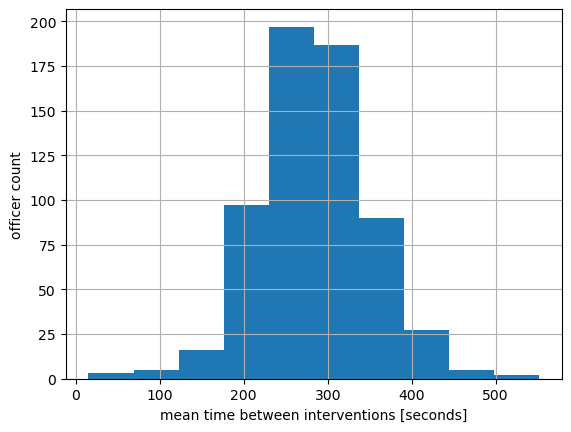

In [43]:
ax0 = wmean_time.astype('timedelta64[s]').div(np.timedelta64(1, 's')).hist()
ax0.set_xlabel("mean time between interventions [seconds]")
ax0.set_ylabel("officer count");

These are the 162307 rows that need imputation (by reducing the excessive 'time_btwn' values):

In [44]:
ime_df.loc[ ime_df['Intervention officer GUID'].isin(wmean_time.index.to_list()) & ime_df['time_btwn'].gt(pd.to_timedelta("20 minutes")) & ime_df['intervention_batch'].ge(0), :]

,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime,time_btwn,start_dtime,intervention_batch,intervention_count
12,b323d292-915c-44ca-8acf-2a23c163abe8,01187ea4-f22b-4fc8-8289-0bccae1c35bc,2023-07-02 06:11:43,INT-12256175-W1X4J-2023-07-02 06:11:50,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,90bb7692-f0cf-eb11-8235-0022481542dd,002727cb-77a9-eb11-9442-0022480fe6d6,NaN,Secondary Examination Area,2023-07-01 20:11:50,0 days 00:35:05,2023-07-02 06:11:43.090,0,4
151,80fab10a-e079-4a9a-ab59-c3678c444886,1d27fd6b-949e-4638-953c-997f564e5a3e,2023-07-02 09:15:03,INT-12258828-S9F9J-2023-07-02 09:15:19,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,90bb7692-f0cf-eb11-8235-0022481542dd,002727cb-77a9-eb11-9442-0022480fe6d6,NaN,Secondary Examination Area,2023-07-01 23:15:19,0 days 00:26:52,2023-07-02 09:15:04.180,1,6
209,c0a2eeea-6ca2-468c-afce-443dddd2f01f,68ebfcfc-6361-4e74-b5da-e4db5f3931bd,2023-07-02 10:30:18,INT-12259564-S2Z4D-2023-07-02 10:30:29,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,e3882fb5-bc24-ed11-9db1-00224812b5bf,6644fc7d-d6aa-ea11-a814-000d3a6a9def,NaN,Secondary Examination Area,2023-07-02 00:30:29,0 days 00:23:37,2023-07-02 10:30:19.660,2,5
262,514b8315-0fcb-48ea-b92f-5dad7bb9b330,0c5d50b6-b5d6-4ada-9056-a6c3d11bbf0b,2023-07-02 11:57:58,INT-12260572-X5X3V-2023-07-02 11:58:7,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,79b7f410-30c9-ed11-b596-0022489331f6,0dc7e22b-d0aa-ea11-a814-000d3a6a9c0e,NaN,Secondary Examination Area,2023-07-02 01:58:07,4 days 18:34:18,2023-07-02 11:58:00.030,3,3
268,86bfcbca-9ae4-4a8e-b2f6-15469cef52e9,6e3750c4-111b-4e66-bd2c-6ab6aa3abc4a,2023-07-07 06:40:48,INT-12299600-Q1S3D-2023-07-07 06:41:14,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,d5a7582c-30c9-ed11-b596-0022489331f6,9693709a-d4aa-ea11-a814-000d3a6a9def,NaN,Secondary Examination Area,2023-07-06 20:41:14,0 days 00:22:04,2023-07-07 06:40:50.060,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3114253,034d21b1-398f-4b2a-86d9-6ef6f186f661,814175ae-f757-4f06-9623-d9e0c56eb3b3,2024-06-26 09:34:09,INT-15112140-D1Z3X-2024-06-26 09:39:34,445290005,445290003,NaN,ff485647-46ba-ee11-9078-0022489330fc,NaN,NaN,NaN,Secondary Examination Area,2024-06-25 23:39:34,0 days 00:26:19,2024-06-26 09:34:15.640,133,1
3114277,008c930f-6f3d-4d71-abce-08964337d5fd,8097357e-83bf-430f-a1d3-0ce32918073d,2024-06-26 11:14:20,INT-15113057-X7D0V-2024-06-26 11:14:28,445290005,445290002,NaN,ff485647-46ba-ee11-9078-0022489330fc,NaN,NaN,NaN,Secondary Examination Area,2024-06-26 01:14:28,0 days 00:36:31,2024-06-26 11:14:26.730,134,1
3114295,4852398d-fe9d-4625-9540-17fa31d79a4e,5f41f780-9060-4aef-8921-0b2a2825e3ed,2024-06-26 13:13:19,INT-15113743-K2K9R-2024-06-26 13:49:7,445290003,445290000,NaN,ff485647-46ba-ee11-9078-0022489330fc,NaN,NaN,NaN,Secondary Examination Area,2024-06-26 03:49:07,0 days 00:35:43,2024-06-26 13:13:25.840,135,2
3114334,b674ef34-04be-4e85-98fe-3df30043cc7f,5392bbda-3773-4f22-85e8-62e7e18edf05,2024-06-27 08:11:59,INT-15118834-S5G4V-2024-06-27 08:12:42,445290003,445290000,NaN,ff485647-46ba-ee11-9078-0022489330fc,NaN,NaN,NaN,Secondary Examination Area,2024-06-26 22:12:42,0 days 00:34:12,2024-06-27 08:12:06.040,136,1


Imputing the mean intervention time for the final sub-batch which starts at the same time, but takes over 20 min before the next batch (this may take a couple of minutes):

In [45]:
for offc in wmean_time.index.to_list():
    # print(offc)
    ime_df['time_btwn'] = ime_df['time_btwn'].mask(ime_df['Intervention officer GUID'].eq(offc) & ime_df['time_btwn'].gt(pd.to_timedelta("20 minutes")) & ime_df['intervention_batch'].ge(0), wmean_time[offc])

Impute the 'time_btwn' values for the end of the final cluster of each officer:

In [46]:
ime_df[ime_df['Intervention officer GUID'].isin([o for o, t in equal_0.index]) &
                             ime_df['Intervention method event start datetime'].isin([t for o, t in equal_0.index]) &
                             ime_df['time_btwn'].eq(pd.to_timedelta("0 seconds")) &
                             ime_df['intervention_batch'].ge(0)]

,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime,time_btwn,start_dtime,intervention_batch,intervention_count
21260,d6cc038b-d178-42ff-b52f-5c13a66b21ee,7e1c133a-fb91-4113-bba2-3d85ee70d0a5,2024-06-23 12:14:45,INT-15090211-H8H2G-2024-06-23 12:14:58,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,d5a7582c-30c9-ed11-b596-0022489331f6,ca62b351-d6aa-ea11-a814-000d3a6a9def,NaN,Secondary Examination Area,2024-06-23 02:14:58,0 days,2024-06-23 12:17:27.330,391,4
21261,812894bc-ce23-4a4d-9f86-042a63efe3db,be19b913-46ec-4cb7-a701-88f821fd91a0,2024-06-23 12:14:45,INT-15090212-Y0R9Y-2024-06-23 12:14:57,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,d5a7582c-30c9-ed11-b596-0022489331f6,ca62b351-d6aa-ea11-a814-000d3a6a9def,NaN,Secondary Examination Area,2024-06-23 02:14:58,0 days,2024-06-23 12:17:27.340,391,4
21262,6ec2d3fb-ec30-4cbd-86c6-841775ecc1ff,330e7a9c-73b0-4c63-ad45-c08e85465224,2024-06-23 12:14:45,INT-15090213-H3P6Z-2024-06-23 12:14:58,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,d5a7582c-30c9-ed11-b596-0022489331f6,ca62b351-d6aa-ea11-a814-000d3a6a9def,NaN,Secondary Examination Area,2024-06-23 02:14:58,0 days,2024-06-23 12:17:27.350,391,4
21263,5b0d78bb-cc8a-4686-8c7c-9a7463b6ba21,22c3000d-414c-4a4c-93ca-7fd20b16ad05,2024-06-23 12:14:45,INT-15090214-N6V6Y-2024-06-23 12:14:58,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,d5a7582c-30c9-ed11-b596-0022489331f6,ca62b351-d6aa-ea11-a814-000d3a6a9def,NaN,Secondary Examination Area,2024-06-23 02:14:58,0 days,2024-06-23 12:17:27.360,391,4
24799,5e20e3b0-9ef6-43c7-886d-f438bfac4eb9,911d3e9a-ff16-4846-89f8-9ae64c56df40,2024-06-30 13:17:44,INT-15148340-L3Q8T-2024-06-30 13:17:52,445290005,445290002,NaN,0116c2cb-c1e4-ee11-904d-002248933647,NaN,NaN,NaN,Secondary Examination Area,2024-06-30 03:17:52,0 days,2024-06-30 13:17:57.220,134,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3078731,6c540ff1-ce3a-4ac1-80e1-cab56d5b3eb0,64406b46-774b-422a-ac99-a83e53e47559,2024-06-28 00:32:59,INT-15124772-J8K5Y-2024-06-28 00:37:16,445290005,445290003,NaN,fa75ad99-87b6-ee11-a568-00224893324d,NaN,NaN,NaN,Secondary Examination Area,2024-06-27 14:37:16,0 days,2024-06-28 00:33:08.090,163,1
3081830,ba0a3acb-2da3-4242-a34e-81596c23334c,a6dd66ce-5861-4eb9-aee3-f36d96ee7cb9,2024-04-13 11:10:51,INT-14545210-K8H5D-2024-04-13 11:12:19,445290003,445290000,NaN,fb01eafb-d4aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-04-13 01:12:19,0 days,2024-04-13 11:11:05.700,141,1
3097529,8ca05b37-5b27-47e4-8033-a73e5b1fdcd5,d72f5ecc-fd4d-44e2-ae20-2a73afd939cc,2024-05-02 08:47:46,INT-14697412-W9N8K-2024-05-02 09:18:24,445290002,445290001,Brown suitcase,fd5fd5b3-d3aa-ea11-a814-000d3a6a9def,4802409b-ff6e-ed11-81ac-002248933fef,d4a98fc0-d2aa-ea11-a814-000d3a6a9def,K9 referral,Secondary Examination Area,2024-05-01 23:18:24,0 days,2024-05-02 08:47:50.790,29,1
3106724,1347d331-69a2-4e01-a3ee-ff89b0ee8589,822e84ba-7d7f-4613-a659-bfaaa90ae85e,2024-06-28 07:44:46,INT-15126370-Q8P3W-2024-06-28 07:44:54,445290005,445290003,NaN,fe185c2a-ac8f-ed11-aad1-002248933b6d,NaN,NaN,NaN,Secondary Examination Area,2024-06-27 21:44:55,0 days,2024-06-28 07:45:29.740,498,1


In [47]:
for offc, tstamp in equal_0.index.to_list():
    ime_df['time_btwn'] = ime_df['time_btwn'].mask(ime_df['Intervention officer GUID'].eq(offc) &
                                                   ime_df['Intervention method event start datetime'].eq(tstamp) &
                                                   ime_df['time_btwn'].eq(pd.to_timedelta("0 seconds")) &
                                                   ime_df['intervention_batch'].ge(0),
                                                   wmean_time[offc])

Now all the interventions with 'time_btwn' exceeding 20 minutes are the non-clustered kind (with label -1):

In [48]:
ime_df.query('time_btwn.gt(@pd.to_timedelta("20 minutes"))')['intervention_batch'].value_counts()

intervention_batch
-1    117321
Name: count, dtype: int64

The 'time_btwn' descriptive statistics:

In [49]:
ime_df.query('time_btwn.gt(@pd.to_timedelta("20 minutes"))')['time_btwn'].describe()

count                       117321
mean     0 days 15:05:17.257694700
std      2 days 19:27:23.027056930
min                0 days 00:20:01
25%                0 days 00:33:39
50%                0 days 01:08:12
75%                0 days 06:09:29
max              259 days 19:37:52
Name: time_btwn, dtype: object

In [50]:
ime_df.query('intervention_batch.lt(0)')['time_btwn'].describe()

count                       263624
mean     0 days 06:44:47.583812551
std      1 days 21:36:58.755508989
min                0 days 00:00:00
25%                0 days 00:00:14
50%                0 days 00:11:42
75%         0 days 00:56:32.250000
max              259 days 19:37:52
Name: time_btwn, dtype: object

Let's save these and all non-clustered interventions into a separate dataframe:

In [51]:
extra_df = ime_df.query('time_btwn.gt(@pd.to_timedelta("20 minutes")) or intervention_batch.lt(0)')
extra_df.shape

(263624, 17)

No dupllcate rows:

In [52]:
extra_df.duplicated().sum()

0

Finally, dropping the interventions with uncertain ending times, i.e., the final intervention of each batch (namely, when the 'time_btwn' exceeds 20 minutes)
and the interventions that have not been assigne to a batch (those with 'intervention_batch' label -1):

In [53]:
# ime_df = ime_df.drop(ime_df.query('time_btwn.gt(@pd.to_timedelta("20 minutes"))').index, axis=0).\
ime_df = ime_df.query('intervention_batch.ge(0)').reset_index(drop=True)

In [54]:
ime_df['time_btwn'].describe()

count                      2850740
mean     0 days 00:02:20.087760721
std      0 days 00:03:38.140367805
min                0 days 00:00:00
25%                0 days 00:00:00
50%                0 days 00:00:13
75%                0 days 00:03:46
max                0 days 00:20:00
Name: time_btwn, dtype: object

Anything gone missing?

In [55]:
3114364 - (ime_df.shape[0] + extra_df.shape[0])

0

And now we can evaluate the 'time_btwn' as the maximum value found in a group with the identical intervention start datetime divided by the size of the group (i.e., 'intervention_count'):

In [56]:
ime_df['time_btwn'] = ime_df.groupby(['Intervention officer GUID', ime_df['Intervention method event start datetime'].round("2s")])['time_btwn'].transform("max").div(ime_df['intervention_count'])

ime_df['time_btwn'].describe()

count                      2850740
mean     0 days 00:02:20.033846650
std      0 days 00:02:52.457458857
min         0 days 00:00:00.100000
25%      0 days 00:00:35.166666666
50%         0 days 00:01:16.500000
75%         0 days 00:02:54.500000
max                0 days 00:20:00
Name: time_btwn, dtype: object

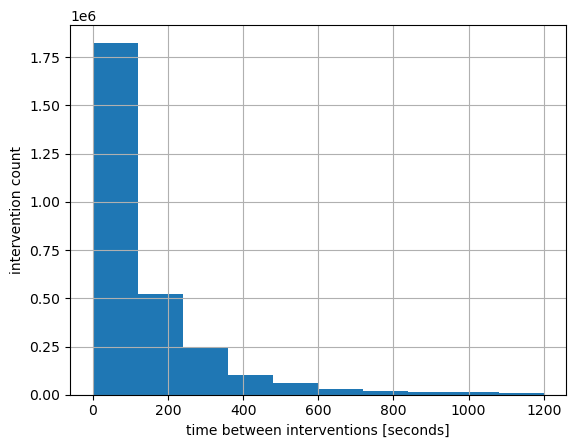

In [57]:
ax1 = ime_df['time_btwn'].astype('timedelta64[s]').div(np.timedelta64(1, 's')).hist()
ax1.set_xlabel("time between interventions [seconds]")
ax1.set_ylabel("intervention count");

There still remain 942 interventions with super short 'time_btwn' values:

In [58]:
ime_df.query('time_btwn.le(@pd.to_timedelta("1 seconds"))')

,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime,time_btwn,start_dtime,intervention_batch,intervention_count
19771,9686e4cc-04dd-49ac-8d64-647912e13e99,7b90c7ae-2224-41f9-a5c6-4770145c3210,2024-06-02 12:21:29,INT-14926813-J7C5D-2024-06-02 12:21:40,445290002,445290001,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,8abb7692-f0cf-eb11-8235-0022481542dd,77cd9aa9-e674-ec11-8943-002248920ae0,K9 referral,Secondary Examination Area,2024-06-02 02:21:40,0 days 00:00:00.333333333,2024-06-02 12:24:00.640,361,3
19772,9ef412a6-698b-4169-8681-46b588cbad04,59dcc2ad-ff61-4065-a86b-43b2828eb78b,2024-06-02 12:21:29,INT-14926816-C2C2W-2024-06-02 12:21:47,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,1d88c300-c889-ee11-be36-00224893324d,74e042d3-1475-ec11-8943-002248920ae0,NaN,Secondary Examination Area,2024-06-02 02:21:47,0 days 00:00:00.333333333,2024-06-02 12:24:00.650,361,3
19773,dcfaffe1-141d-41d2-b876-986ae80f155c,e9f884bd-59be-4a35-9941-637899f53831,2024-06-02 12:21:29,INT-14926817-P5Y2L-2024-06-02 12:21:48,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,1d88c300-c889-ee11-be36-00224893324d,74e042d3-1475-ec11-8943-002248920ae0,NaN,Secondary Examination Area,2024-06-02 02:21:48,0 days 00:00:00.333333333,2024-06-02 12:24:00.660,361,3
42357,c3b163c2-b4e1-4818-a50b-84ed1eb81dfe,4372f11b-98f0-4ae2-9c64-c9f295d9e3ef,2023-12-19 11:06:03,INT-13642535-F8H4S-2023-12-19 11:07:32,445290002,445290000,NaN,0315f2f5-d4aa-ea11-a814-000d3a6a9def,c4e769bd-ff6e-ed11-81ac-002248933fef,3665649a-73a9-eb11-9442-0022480fe806,NaN,Secondary Examination Area,2023-12-19 00:07:32,0 days 00:00:00.166666666,2023-12-19 11:06:07.240,58,6
42358,752bfb94-e0cd-4428-b9da-6b963d95e8ce,27e34714-b0b9-4ed0-a3b5-47895e6e5f76,2023-12-19 11:06:03,INT-13642536-P9H6K-2023-12-19 11:07:31,445290002,445290000,NaN,0315f2f5-d4aa-ea11-a814-000d3a6a9def,c4e769bd-ff6e-ed11-81ac-002248933fef,3665649a-73a9-eb11-9442-0022480fe806,NaN,Secondary Examination Area,2023-12-19 00:07:31,0 days 00:00:00.166666666,2023-12-19 11:06:07.250,58,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2845038,a5cc52ce-c9b2-42d1-a0ae-3b6f7a31893c,46907226-8bb6-4ba8-b105-59fabc68eec2,2023-09-27 20:44:42,INT-12982643-M0J3Y-2023-09-27 20:44:54,445290003,445290000,NaN,ff36baa6-d5aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2023-09-27 10:44:54,0 days 00:00:01,2023-09-27 20:44:45.890,79,8
2845039,690d6001-47f9-4e3f-ab20-3c9c716a981b,792bcf53-949c-4530-adba-f3db543bfff4,2023-09-27 20:44:42,INT-12982644-G6F6V-2023-09-27 20:44:54,445290003,445290000,NaN,ff36baa6-d5aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2023-09-27 10:44:54,0 days 00:00:01,2023-09-27 20:44:45.900,79,8
2845040,1556abf6-ae00-484f-a33e-095ee6e2cd6c,f82dc7f9-dae2-4a9a-92ba-f4e7be61c62c,2023-09-27 20:44:42,INT-12982645-V5Z6H-2023-09-27 20:44:54,445290003,445290000,NaN,ff36baa6-d5aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2023-09-27 10:44:54,0 days 00:00:01,2023-09-27 20:44:45.910,79,8
2845041,00aba09c-aff1-4600-9546-4d73d177568d,62441128-fc36-4a56-9265-96441fd57a9e,2023-09-27 20:44:42,INT-12982646-T3Y0G-2023-09-27 20:44:55,445290003,445290000,NaN,ff36baa6-d5aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2023-09-27 10:44:55,0 days 00:00:01,2023-09-27 20:44:45.920,79,8


In [59]:
dmean_time = ime_df.groupby('Intervention officer GUID')['time_btwn'].mean().round("1s")

dmean_time

Intervention officer GUID
002727cb-77a9-eb11-9442-0022480fe6d6   0 days 00:01:10.406226379
0030689c-d2aa-ea11-a814-000d3a6a9def   0 days 00:02:35.305555555
0116c2cb-c1e4-ee11-904d-002248933647   0 days 00:02:43.984524686
01493553-d3aa-ea11-a814-000d3a6a9def   0 days 00:03:05.521315468
0161e610-d1aa-ea11-a814-000d3a6a9def   0 days 00:02:08.132825719
                                                  ...           
fcd011f6-d3aa-ea11-a814-000d3a6a9def   0 days 00:02:30.864655632
fd5fd5b3-d3aa-ea11-a814-000d3a6a9def   0 days 00:01:15.812389380
fe185c2a-ac8f-ed11-aad1-002248933b6d   0 days 00:02:46.193741428
ff36baa6-d5aa-ea11-a814-000d3a6a9def   0 days 00:02:17.487981280
ff485647-46ba-ee11-9078-0022489330fc   0 days 00:03:39.258924321
Name: time_btwn, Length: 625, dtype: timedelta64[ns]

The distribution of the average 'time_btwn' for all the officers:

In [60]:
dmean_time.describe()

count                          625
mean     0 days 00:02:28.275190130
std      0 days 00:00:42.424876038
min      0 days 00:00:03.846153845
25%      0 days 00:02:02.928892889
50%      0 days 00:02:29.242570579
75%      0 days 00:02:55.333333333
max      0 days 00:05:05.037974683
Name: time_btwn, dtype: object

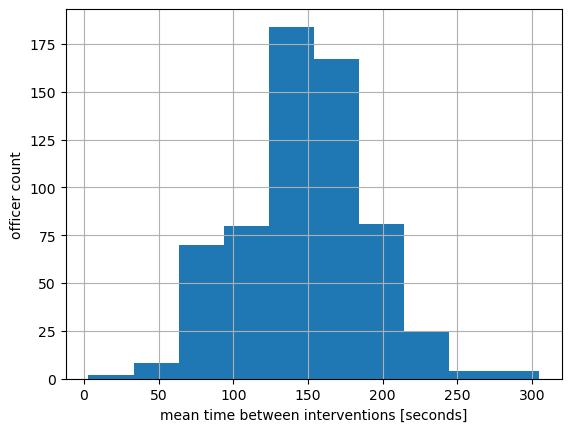

In [61]:
ax2 = dmean_time.astype('timedelta64[s]').div(np.timedelta64(1, 's')).hist()
ax2.set_xlabel("mean time between interventions [seconds]")
ax2.set_ylabel("officer count");

In [62]:
ime_df['time_btwn'].sum().round("1s")

Timedelta('4620 days 08:54:48')

In [63]:
ime_df.groupby('Intervention method ID', observed=True)['time_btwn'].describe().rename(index={293050001: "Survey",
                                                                                              445290000: "Rover",
                                                                                              445290001: "Marshal",
                                                                                              445290002: "Detector dog",
                                                                                              445290003: "2D X-Ray",
                                                                                              445290004: "3D X-Ray",
                                                                                              445290005: "Inspection bench"}).astype('timedelta64[s]')

,count,mean,std,min,25%,50%,75%,max
Intervention method ID,,,,,,,,
Survey,0 days,0 days 00:07:37,0 days 00:04:59,0 days 00:00:06,0 days 00:04:12,0 days 00:06:52,0 days 00:11:00,0 days 00:20:00
Rover,0 days,0 days 00:02:47,0 days 00:03:33,0 days 00:00:05,0 days 00:00:26,0 days 00:01:26,0 days 00:03:45,0 days 00:20:00
Marshal,0 days,0 days 00:02:27,0 days 00:03:12,0 days 00:00:05,0 days 00:00:17,0 days 00:01:13,0 days 00:03:20,0 days 00:19:56
Detector dog,0 days,0 days 00:01:03,0 days 00:01:20,0 days 00:00:00,0 days 00:00:25,0 days 00:00:41,0 days 00:01:11,0 days 00:20:00
2D X-Ray,0 days,0 days 00:02:12,0 days 00:02:31,0 days 00:00:00,0 days 00:00:41,0 days 00:01:23,0 days 00:02:44,0 days 00:20:00
Inspection bench,0 days,0 days 00:03:16,0 days 00:03:24,0 days 00:00:00,0 days 00:00:55,0 days 00:02:09,0 days 00:04:27,0 days 00:20:00


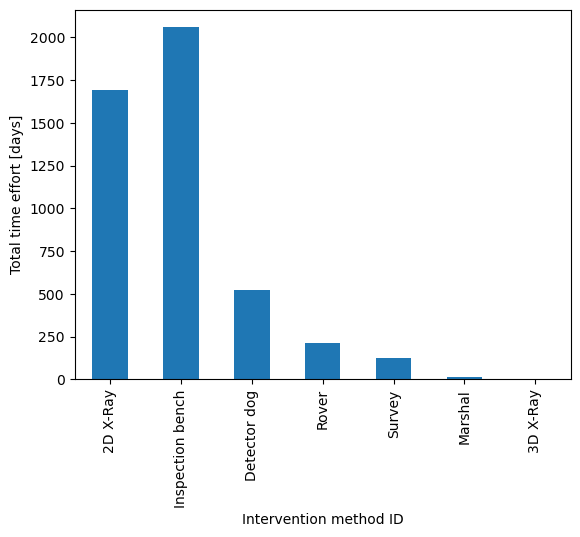

In [64]:
ax3 = ime_df[ime_df['Intervention method event start datetime'].between(pd.to_datetime("2023-07-01 00:00:01"), pd.to_datetime("2024-06-30 23:59:50"))]\
    .groupby('Intervention method ID', observed=True)['time_btwn'].sum().rename(index={293050001: "Survey",
                                                                                       445290000: "Rover",
                                                                                       445290001: "Marshal",
                                                                                       445290002: "Detector dog",
                                                                                       445290003: "2D X-Ray",
                                                                                       445290004: "3D X-Ray",
                                                                                       445290005: "Inspection bench"})\
    .reindex(index=["2D X-Ray", "Inspection bench", "Detector dog", "Rover", "Survey", "Marshal", "3D X-Ray"]).dt.days.plot(kind="bar")
#   .reindex(index=["2D X-Ray", "Inspection bench", "Detector dog", "Rover", "Survey", "Marshal", "3D X-Ray"]).astype('timedelta64[D]').plot(kind="bar")  BROKEN!

ax3.set_ylabel("Total time effort [days]");

In [74]:
ime_df[ime_df['Intervention method event start datetime'].between(pd.to_datetime("2023-07-01 00:00:01"), pd.to_datetime("2024-06-30 23:59:50"))]\
    .groupby('Intervention method ID', observed=True)[['time_btwn']].agg(lambda x: x.sum().round('1s')).rename(index={293050001: "Survey",
                                                                                       445290000: "Rover",
                                                                                       445290001: "Marshal",
                                                                                       445290002: "Detector dog",
                                                                                       445290003: "2D X-Ray",
                                                                                       445290004: "3D X-Ray",
                                                                                       445290005: "Inspection bench"})\
    .reindex(index=["2D X-Ray", "Inspection bench", "Detector dog", "Rover", "Survey", "Marshal", "3D X-Ray"]).fillna("0 days").rename(columns={'time_btwn': "Total time effort"})

,Total time effort
Intervention method ID,
2D X-Ray,1692 days 03:22:11
Inspection bench,2058 days 21:01:46
Detector dog,522 days 07:06:28
Rover,212 days 05:30:08
Survey,123 days 10:14:03
Marshal,11 days 09:31:33
3D X-Ray,0 days 00:00:00


Alternatively, one may attempt to identify clusters "manually":

In [65]:
alt_df = pd.read_csv("./FY2324.csv.gz", parse_dates=['Intervention method event start datetime', 'Creation datetime'])

for c in ('Intervention method ID', 'Intervention outcome ID', 'Detector dog GUID', 'Detector dog handler GUID', 'Location'):
    alt_df[c] = alt_df[c].astype("category")

alt_df = alt_df.sort_values(by=['Intervention officer GUID', 'Intervention method event start datetime', 'Intervention method event ID'], ascending=[True, True, True], ignore_index=True)

alt_df = alt_df.assign(time_btwn=ime_df.groupby('Intervention officer GUID')['Intervention method event start datetime'].diff().shift(-1))

In [66]:
alt_df = alt_df.assign(intervention_batch=-1)

alt_df['intervention_batch'] = alt_df.groupby('Intervention officer GUID')['time_btwn'].transform(lambda x: x.ge(pd.to_timedelta("20 minutes")).cumsum())

In [67]:
alt_df['intervention_batch'].value_counts()

intervention_batch
0       271868
3        11067
1        10744
2        10653
5        10457
         ...  
1114         5
1168         5
1127         5
1192         5
1169         5
Name: count, Length: 1220, dtype: int64

In [68]:
alt_df.query('`Intervention officer GUID` == "002727cb-77a9-eb11-9442-0022480fe6d6"')['intervention_batch'].value_counts()

intervention_batch
9      210
11     207
20     189
99     189
175    186
      ... 
272      5
374      5
65       5
78       5
153      5
Name: count, Length: 398, dtype: int64

In [69]:
alt_df['time_btwn'] = alt_df['time_btwn'].fillna(pd.Timedelta(seconds=0))

In [70]:
alt_df['time_btwn'].describe()

count                      3114364
mean     0 days 01:21:00.972364823
std      0 days 20:31:39.031105295
min                0 days 00:00:00
25%                0 days 00:00:00
50%                0 days 00:00:00
75%                0 days 00:03:25
max              265 days 20:36:16
Name: time_btwn, dtype: object

In [71]:
alt_df.loc[ alt_df['Intervention officer GUID'].isin(wmean_time.index.to_list()) & alt_df['time_btwn'].gt(pd.to_timedelta("20 minutes")), :]

,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime,time_btwn,intervention_batch
12,b323d292-915c-44ca-8acf-2a23c163abe8,01187ea4-f22b-4fc8-8289-0bccae1c35bc,2023-07-02 06:11:43,INT-12256175-W1X4J-2023-07-02 06:11:50,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,90bb7692-f0cf-eb11-8235-0022481542dd,002727cb-77a9-eb11-9442-0022480fe6d6,NaN,Secondary Examination Area,2023-07-01 20:11:50,0 days 00:35:05,1
151,80fab10a-e079-4a9a-ab59-c3678c444886,1d27fd6b-949e-4638-953c-997f564e5a3e,2023-07-02 09:15:03,INT-12258828-S9F9J-2023-07-02 09:15:19,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,90bb7692-f0cf-eb11-8235-0022481542dd,002727cb-77a9-eb11-9442-0022480fe6d6,NaN,Secondary Examination Area,2023-07-01 23:15:19,0 days 00:26:52,2
209,c0a2eeea-6ca2-468c-afce-443dddd2f01f,68ebfcfc-6361-4e74-b5da-e4db5f3931bd,2023-07-02 10:30:18,INT-12259564-S2Z4D-2023-07-02 10:30:29,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,e3882fb5-bc24-ed11-9db1-00224812b5bf,6644fc7d-d6aa-ea11-a814-000d3a6a9def,NaN,Secondary Examination Area,2023-07-02 00:30:29,0 days 00:23:37,3
262,514b8315-0fcb-48ea-b92f-5dad7bb9b330,0c5d50b6-b5d6-4ada-9056-a6c3d11bbf0b,2023-07-02 11:57:58,INT-12260572-X5X3V-2023-07-02 11:58:7,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,79b7f410-30c9-ed11-b596-0022489331f6,0dc7e22b-d0aa-ea11-a814-000d3a6a9c0e,NaN,Secondary Examination Area,2023-07-02 01:58:07,4 days 18:34:18,4
268,86bfcbca-9ae4-4a8e-b2f6-15469cef52e9,6e3750c4-111b-4e66-bd2c-6ab6aa3abc4a,2023-07-07 06:40:48,INT-12299600-Q1S3D-2023-07-07 06:41:14,445290002,445290000,NaN,002727cb-77a9-eb11-9442-0022480fe6d6,d5a7582c-30c9-ed11-b596-0022489331f6,9693709a-d4aa-ea11-a814-000d3a6a9def,NaN,Secondary Examination Area,2023-07-06 20:41:14,0 days 00:22:04,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2850629,e765b3a6-a6a0-461a-8f14-3c7b1b932a29,6a95c4dc-7537-40e1-b0fe-c9506e2fcf25,2024-03-30 17:13:07,INT-14435207-Y4S8K-2024-03-30 18:13:36,445290002,445290000,NaN,e7e0bfd8-d6aa-ea11-a814-000d3a6a96b8,b8bb7692-f0cf-eb11-8235-0022481542dd,6f80ccc5-d3aa-ea11-a814-000d3a6a9def,NaN,Secondary Examination Area,2024-03-30 07:13:36,0 days 00:41:56,553
2850636,0533685f-d59f-4b3e-ae2d-1a1ac815b3b2,d193c1c4-e3b5-46f4-9f0c-19928b158e32,2024-03-30 17:13:07,INT-14435214-V2N5W-2024-03-30 18:13:37,445290002,445290000,NaN,e7e0bfd8-d6aa-ea11-a814-000d3a6a96b8,b8bb7692-f0cf-eb11-8235-0022481542dd,6f80ccc5-d3aa-ea11-a814-000d3a6a9def,NaN,Secondary Examination Area,2024-03-30 07:13:37,0 days 00:26:19,554
2850660,64354924-8cc1-4ea8-83a5-8c4593777180,0a25686f-a1ff-4071-b440-1779bbc9b966,2024-03-30 17:26:06,INT-14435371-H5P1C-2024-03-30 18:26:43,445290002,445290000,NaN,e7e0bfd8-d6aa-ea11-a814-000d3a6a96b8,b8bb7692-f0cf-eb11-8235-0022481542dd,6f80ccc5-d3aa-ea11-a814-000d3a6a9def,NaN,Secondary Examination Area,2024-03-30 07:26:43,0 days 01:19:23,555
2850674,668ee7e6-2b4b-4a87-81db-94cab85811ee,9dddcc05-1a4a-414e-8ea2-6620e61cb028,2024-03-30 17:35:28,INT-14435460-N8J6K-2024-03-30 18:36:32,445290002,445290000,NaN,e7e0bfd8-d6aa-ea11-a814-000d3a6a96b8,b8bb7692-f0cf-eb11-8235-0022481542dd,6f80ccc5-d3aa-ea11-a814-000d3a6a9def,NaN,Secondary Examination Area,2024-03-30 07:36:32,0 days 17:40:19,556


In [72]:
for offc in wmean_time.index.to_list():
    # print(offc)
    alt_df['time_btwn'] = alt_df['time_btwn'].mask(alt_df['Intervention officer GUID'].eq(offc) & alt_df['time_btwn'].gt(pd.to_timedelta("20 minutes")), wmean_time[offc])

In [73]:
alt_df[alt_df['Intervention officer GUID'].isin([o for o, t in equal_0.index]) &
                             alt_df['Intervention method event start datetime'].isin([t for o, t in equal_0.index]) &
                             alt_df['time_btwn'].eq(pd.to_timedelta("0 seconds"))]

,Intervention GUID,Intervention method event GUID,Intervention method event start datetime,Intervention method event ID,Intervention method ID,Intervention outcome ID,Intervention method event comment,Intervention officer GUID,Detector dog GUID,Detector dog handler GUID,Reason summary,Location,Creation datetime,time_btwn,intervention_batch
24799,5e20e3b0-9ef6-43c7-886d-f438bfac4eb9,911d3e9a-ff16-4846-89f8-9ae64c56df40,2024-06-30 13:17:44,INT-15148340-L3Q8T-2024-06-30 13:17:52,445290005,445290002,NaN,0116c2cb-c1e4-ee11-904d-002248933647,NaN,NaN,NaN,Secondary Examination Area,2024-06-30 03:17:52,0 days,137
37419,be28fca2-fbba-415e-b17a-4cf3f7af3ff7,f5cdf9a9-f13b-403e-94cc-a25bbd1bf71b,2024-02-18 10:59:08,INT-14143286-C6D8D-2024-02-18 12:10:40,445290005,445290003,NaN,02c902d9-d0aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-02-18 01:10:40,0 days,4
43308,666799d2-0694-4ac3-b59f-18ec0342db39,6956502d-cb30-4a2d-a162-64c6783201fa,2024-05-21 23:36:13,INT-14839093-Y6L0T-2024-05-21 23:37:40,445290005,445290002,NaN,030f321a-d4aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-05-21 13:37:40,0 days,392
48198,f09b1fb0-f8b5-47e9-ae53-8712d9224fd6,3fc5f673-cec7-4cb6-a436-d190221c6a3b,2024-06-20 20:48:17,INT-15066616-D4X2M-2024-06-20 20:48:27,445290003,445290000,NaN,0315f2f5-d4aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-06-20 10:48:27,0 days,248
58160,c55b742a-0434-44f8-a43c-5a84d2d6c5b7,7780b07e-6da9-4f5a-b8e9-8aca14403cff,2024-06-28 11:04:50,INT-15129021-T1M9D-2024-06-28 11:11:51,445290005,445290002,NaN,03259f49-b44a-ed11-bba2-002248933bc9,NaN,NaN,NaN,Secondary Examination Area,2024-06-28 01:11:51,0 days,517
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3078731,6c540ff1-ce3a-4ac1-80e1-cab56d5b3eb0,64406b46-774b-422a-ac99-a83e53e47559,2024-06-28 00:32:59,INT-15124772-J8K5Y-2024-06-28 00:37:16,445290005,445290003,NaN,fa75ad99-87b6-ee11-a568-00224893324d,NaN,NaN,NaN,Secondary Examination Area,2024-06-27 14:37:16,0 days,0
3081830,ba0a3acb-2da3-4242-a34e-81596c23334c,a6dd66ce-5861-4eb9-aee3-f36d96ee7cb9,2024-04-13 11:10:51,INT-14545210-K8H5D-2024-04-13 11:12:19,445290003,445290000,NaN,fb01eafb-d4aa-ea11-a814-000d3a6a9def,NaN,NaN,NaN,Secondary Examination Area,2024-04-13 01:12:19,0 days,0
3097529,8ca05b37-5b27-47e4-8033-a73e5b1fdcd5,d72f5ecc-fd4d-44e2-ae20-2a73afd939cc,2024-05-02 08:47:46,INT-14697412-W9N8K-2024-05-02 09:18:24,445290002,445290001,Brown suitcase,fd5fd5b3-d3aa-ea11-a814-000d3a6a9def,4802409b-ff6e-ed11-81ac-002248933fef,d4a98fc0-d2aa-ea11-a814-000d3a6a9def,K9 referral,Secondary Examination Area,2024-05-01 23:18:24,0 days,0
3106724,1347d331-69a2-4e01-a3ee-ff89b0ee8589,822e84ba-7d7f-4613-a659-bfaaa90ae85e,2024-06-28 07:44:46,INT-15126370-Q8P3W-2024-06-28 07:44:54,445290005,445290003,NaN,fe185c2a-ac8f-ed11-aad1-002248933b6d,NaN,NaN,NaN,Secondary Examination Area,2024-06-27 21:44:55,0 days,0


In [74]:
for offc, tstamp in equal_0.index.to_list():
    alt_df['time_btwn'] = alt_df['time_btwn'].mask(alt_df['Intervention officer GUID'].eq(offc) &
                                                   alt_df['Intervention method event start datetime'].eq(tstamp) &
                                                   alt_df['time_btwn'].eq(pd.to_timedelta("0 seconds")),
                                                   wmean_time[offc])

In [75]:
alt_df.time_btwn.sum()

Timedelta('4610 days 14:33:40')

In [76]:
alt_df['time_btwn'].describe()

count                      3114364
mean     0 days 00:02:07.909396589
std      0 days 00:03:31.817304543
min                0 days 00:00:00
25%                0 days 00:00:00
50%                0 days 00:00:00
75%                0 days 00:03:23
max                0 days 00:20:00
Name: time_btwn, dtype: object